# Update 10 — Quantifying the 1/R(t) term in the anchor-offset contribution

**Measurement chain.** The derived index is

    n_data(t) = K * n_780(T,H,P) / R(t),        K = f_780 / f_1762

A *constant* multiplicative anchor changes only the intercept of a fit of n_data on [1, T, H, P] and cancels in alpha_data - alpha_Mathar. A *time dependent* factor 1/R(t) does not: its slow component is correlated with the environmental regressors (corr(T, t) = 0.74 here) and therefore leaks into the fitted coefficients.

**Two questions.**

1. *Leverage*: how much does a slow multiplicative perturbation of amplitude a [ppm] shift the fitted humidity difference d(alpha_H)?
2. *Observable*: what slow component is actually present in R(t), and how much does it inject into d(alpha_H)?

**Sign conventions (kept explicit).**

- eps_n(t) = delta n / n  ->  d(dH) = [(X'X)^-1 X' (n * eps_n)]_H
- eps_R(t) = delta R / R  ->  eps_n = -eps_R to first order, so d(dH) = -[(X'X)^-1 X' (n * eps_R)]_H

All amplitudes are quoted in ppm of the *relative* perturbation.

**Gate (card §2.1).** Before interpreting any perturbation, the unperturbed full-resolution difference must reproduce the archived value d(alpha_H) = +4.3334e-9.

**Output.** `one_over_R_term.json` (next to this notebook) plus the tables and figure below.

In [1]:
# Setup: data, measurement chain, baseline gate

import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
from chain_propagation import Models, calibrate_K

DATA   = '../../data/processed/full_data.csv'
MODELS = '../models/'

mo = Models(MODELS + 'nist/refractive_index.py', MODELS + 'mathar/Mathar2007.py')

df = pd.read_csv(DATA)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)
N = len(df)

T = df.temperature.values.astype(float)
H = df.humidity.values.astype(float)
P = df.pressure.values.astype(float)
R = df.counts_ratio.values.astype(float)
y = df.n_1762.values.astype(float)

tsec   = df['time'].values.astype('int64') / 1e9
tsec  -= tsec[0]
t_norm = tsec / (tsec[-1] - tsec[0])                       # 0..1 over campaign
t_abs  = (df['time'].values.astype('datetime64[s]')
          - np.datetime64('2025-01-01')) / np.timedelta64(1, 'D')

X       = np.column_stack([np.ones(N), T, H, P])           # [1, T, H, P]
XtX_inv = np.linalg.inv(X.T @ X)

K, n780 = calibrate_K(mo, T, H, P, R, y)                   # reconstruction check
y_rec   = K * n780 / R
nm      = mo.mathar(1.762, T, P, H)                        # Mathar at the same readings
lnR     = np.log(R)

def beta(yv):
    return np.linalg.lstsq(X, yv, rcond=None)[0]

def fitm(mask, yv):
    Xm = np.column_stack([np.ones(int(mask.sum())), T[mask], H[mask], P[mask]])
    return np.linalg.lstsq(Xm, yv[mask], rcond=None)[0]

def dH_mask(mask):
    return fitm(mask, y_rec)[2] - fitm(mask, nm)[2]

allm = np.ones(N, bool)
dH0  = dH_mask(allm)

print(f'N                   = {N}')
print(f'gate dH (archived)  = {1e9*(beta(y)[2]-beta(nm)[2]):+.6f} e-9   (expected +4.3334)')
print(f'gate dH (recon)     = {1e9*dH0:+.6f} e-9')
print(f'n_bar               = {y_rec.mean():.8f}')
print(f'corr(T, t)          = {np.corrcoef(T, t_norm)[0,1]:+.4f}')
print(f'cond(X)             = {np.linalg.cond(X):.3e}')

N                   = 145784
gate dH (archived)  = +4.333401 e-9   (expected +4.3334)
gate dH (recon)     = +4.333405 e-9
n_bar               = 1.00025433
corr(T, t)          = +0.7431
cond(X)             = 2.304e+05


## A. Leverage of slow shapes on d(alpha_H)

Candidate slow shapes (unit amplitude), defined on the observation times:
half-year step, linear ramp, quadratic, annual sine. The leverage is the
first-order response of the fitted coefficient difference; the exact-refit
column verifies it with a 1 ppm perturbation.

In [2]:
shapes = {
    'half-year step': (t_abs >= 90.0).astype(float),
    'linear ramp'   : t_norm,
    'quadratic'     : t_norm ** 2,
    'annual sin'    : np.sin(2 * np.pi * t_abs / 365.25),
}

print('Leverage of unit-amplitude slow shapes on d(alpha_H)')
print('  eps_n(t) = a * s(t),  a = 1 ppm')
print(f'{"shape":16s} {"beta_s,H":>12s} {"L_s":>12s} {"d(dH)/ppm":>14s} {"exact refit":>14s}')
lev = {}
for name, s in shapes.items():
    beta_s = np.linalg.lstsq(X, s, rcond=None)[0][2]
    L      = float((XtX_inv @ (X.T @ (y_rec * s)))[2])
    exact  = 1e9 * (beta(y_rec * (1 + 1e-6 * s))[2] - beta(y_rec)[2])
    lev[name] = {'beta_s': float(beta_s), 'L_s': L, 'dH_per_ppm_e9': 1e3 * L}
    print(f'{name:16s} {beta_s:+12.4e} {L:+12.4e} {1e3*L:+11.3f}e-9 {exact:+11.3f}e-9')
print()
print('eps_n = -eps_R to first order, so a R-drift shape injects d(dH) = -L_s per ppm of eps_R.')
print('The leverage is large because the slow shapes are collinear with T (corr = 0.74).')

Leverage of unit-amplitude slow shapes on d(alpha_H)
  eps_n(t) = a * s(t),  a = 1 ppm
shape                beta_s,H          L_s      d(dH)/ppm    exact refit
half-year step    +2.6052e-03  +2.6059e-03      +2.606e-9      +2.606e-9
linear ramp       +1.0597e-02  +1.0600e-02     +10.600e-9     +10.600e-9
quadratic         +1.6656e-02  +1.6660e-02     +16.660e-9     +16.660e-9
annual sin        -3.2534e-02  -3.2542e-02     -32.542e-9     -32.542e-9

eps_n = -eps_R to first order, so a R-drift shape injects d(dH) = -L_s per ppm of eps_R.
The leverage is large because the slow shapes are collinear with T (corr = 0.74).


## B. Observed slow component in R(t)

Three estimators, from least to most conservative:

- **(a) joint regression** ln R ~ [1, T, H, P, t] — not identifiable, because t
  is collinear with T (corr = 0.74).
- **(b) fixed-environment (within-bin) trend** — de-mean ln R and t within
  bins of temperature, optionally with within-bin T, H, P controls.
- **(c) monthly-mean residual shape** after removing [1, T, H, P] — the
  data-driven slow component used for the injection estimate.

Note on (b): with T-only bins the trend is stable at about -0.3 ppm/campaign.
With (T,H,P) cells it shrinks and loses significance as the cells get finer,
because t becomes collinear with the cell dummies: the coefficient becomes
*unidentified rather than zero*. This is a statement about identifiability,
not evidence that the drift vanishes.

In [3]:
# (a) joint fit
Xj = np.column_stack([X, t_norm])
bj = np.linalg.lstsq(Xj, lnR, rcond=None)[0]
s2j = ((lnR - Xj @ bj) ** 2).sum() / (N - 5)
sej = np.sqrt(s2j * np.linalg.inv(Xj.T @ Xj)[-1, -1])
print(f'(a) joint fit lnR ~ [1,T,H,P,t]: slope = {1e6*bj[-1]:+.3f} ppm/campaign '
      f'(t = {bj[-1]/sej:+.0f})')

# (b) fixed-environment within-bin trend
def fe_trend(keys, w, controls):
    bins = np.zeros(N, dtype=np.int64)
    for v in keys:
        a = {'T': T, 'H': H, 'P': P}[v]
        bins = bins * 100000 + np.floor((a - a.min()) / w).astype(np.int64)
    _, bins = np.unique(bins, return_inverse=True)
    Z = np.column_stack([lnR] + ([T, H, P] if controls else []))
    for j in range(Z.shape[1]):
        Z[:, j] -= pd.Series(Z[:, j]).groupby(bins).transform('mean').values
    tt = t_norm - pd.Series(t_norm).groupby(bins).transform('mean').values
    A = np.column_stack([Z[:, 1:], tt]) if controls else tt[:, None]
    c, *_ = np.linalg.lstsq(A, Z[:, 0], rcond=None)
    s2 = ((Z[:, 0] - A @ c) ** 2).sum() / (N - A.shape[1])
    se = np.sqrt(s2 * np.linalg.inv(A.T @ A)[-1, -1])
    return 1e6 * c[-1], c[-1] / se

print('\n(b) within-bin (fixed-effects) trend of lnR, ppm/campaign:')
print(f'{"bin width":>10s} | {"T-bins":>18s} | {"T-bins + T,H,P":>22s} | {"(T,H,P) cells":>20s}')
fe_tab = {}
for w in (2.0, 1.0, 0.5, 0.25):
    a  = fe_trend(['T'], w, False)
    a2 = fe_trend(['T'], w, True)
    b3 = fe_trend(['T', 'H', 'P'], w, True)
    fe_tab[w] = {'T': a, 'T_ctrl': a2, 'THP': b3}
    print(f'{w:>9.2f}C | {a[0]:+8.3f} (t={a[1]:+5.1f}) | {a2[0]:+8.3f} (t={a2[1]:+5.1f}) | '
          f'{b3[0]:+8.3f} (t={b3[1]:+5.1f})')

# (c) monthly-mean residual shape
resid = lnR - X @ np.linalg.lstsq(X, lnR, rcond=None)[0]
mon   = df['time'].dt.month.values
mm    = pd.Series(resid).groupby(mon).mean()
epsR  = pd.Series(mon).map(mm).values
inj_R = -float((XtX_inv @ (X.T @ (y_rec * epsR)))[2])
inj_n = 1e9 * (beta(y_rec * (1 + epsR))[2] - beta(y_rec)[2])

print('\n(c) monthly-mean residual of lnR (ppm):')
for m in sorted(mm.index):
    print(f'    month {int(m):2d}: {1e6*mm[m]:+.3f} ppm   (n = {(mon==m).sum()})')
print(f'    amplitude (max-min) = {1e6*(mm.max()-mm.min()):.3f} ppm')
print(f'    injection into d(alpha_H): via eps_R = {1e9*inj_R:+.3f}e-9 | '
      f'via eps_n = {inj_n:+.3f}e-9')

(a) joint fit lnR ~ [1,T,H,P,t]: slope = -0.411 ppm/campaign (t = -137)

(b) within-bin (fixed-effects) trend of lnR, ppm/campaign:
 bin width |             T-bins |         T-bins + T,H,P |        (T,H,P) cells
     2.00C |   -0.304 (t=-46.9) |   -0.344 (t=-49.5) |   -0.335 (t=-26.4)
     1.00C |   -0.322 (t=-49.0) |   -0.335 (t=-47.2) |   -0.122 (t= -6.2)
     0.50C |   -0.328 (t=-49.6) |   -0.341 (t=-47.5) |   -0.055 (t= -1.6)
     0.25C |   -0.323 (t=-47.7) |   -0.336 (t=-45.9) |   +0.076 (t= +1.5)

(c) monthly-mean residual of lnR (ppm):
    month  1: +0.085 ppm   (n = 12109)
    month  2: -0.031 ppm   (n = 25)
    month  6: +0.089 ppm   (n = 28911)
    month  7: -0.013 ppm   (n = 54397)
    month  8: -0.058 ppm   (n = 50342)
    amplitude (max-min) = 0.147 ppm
    injection into d(alpha_H): via eps_R = +4.374e-9 | via eps_n = -4.374e-9


## C. Injection into d(alpha_H) and cross-checks

The two data-driven slow-component estimates (joint-fit ramp and monthly-mean
shape) are injected through the leverage. The two-block split is a consistency
check: a global ramp shifts both blocks by the same amount, so it cannot
distinguish a drift from a genuine humidity response.

Injection into d(alpha_H) for the observed slow component
(sign convention: eps_R = delta R / R; per-ppm values are -L_s)
shape              per ppm eps_R      injection  note
half-year step         -2.606e-9      -0.383e-9  |amplitude| = 0.147 ppm (sign unknown)
linear ramp           -10.600e-9      +4.357e-9  observed slope -0.411 ppm
quadratic             -16.660e-9      -2.448e-9  |amplitude| = 0.147 ppm (sign unknown)
annual sin            +32.542e-9      +4.782e-9  |amplitude| = 0.147 ppm (sign unknown)
monthly shape                  -      +4.374e-9  data-driven signed shape

Two-block d(alpha_H): Jan-Feb = +4.622e-9 (n=12134) | Jun-Aug = +3.658e-9 (n=133650) | difference = +0.964e-9


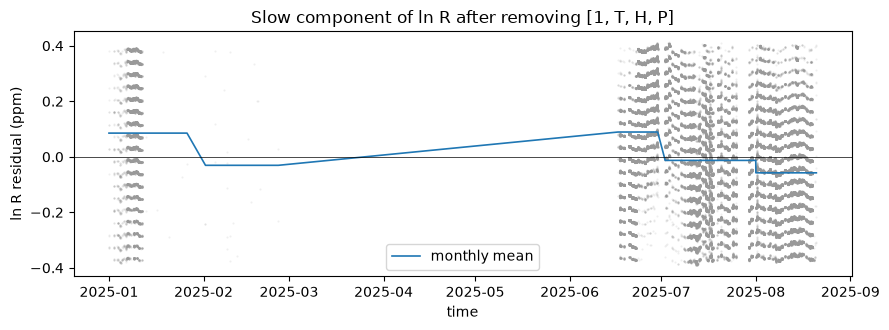

In [4]:
print('Injection into d(alpha_H) for the observed slow component')
print('(sign convention: eps_R = delta R / R; per-ppm values are -L_s)')
amp_month   = 1e6 * (mm.max() - mm.min())
ramp_signed = 1e6 * bj[-1]            # signed observed slope, ppm/campaign
print(f'{"shape":16s} {"per ppm eps_R":>15s} {"injection":>14s}  note')
for name in shapes:
    per_ppm_R = -1e3 * lev[name]['L_s']
    if name == 'linear ramp':
        inj  = per_ppm_R * ramp_signed
        note = f'observed slope {ramp_signed:+.3f} ppm'
    else:
        inj  = per_ppm_R * amp_month
        note = f'|amplitude| = {amp_month:.3f} ppm (sign unknown)'
    print(f'{name:16s} {per_ppm_R:+12.3f}e-9 {inj:+11.3f}e-9  {note}')
print(f'{"monthly shape":16s} {"-":>15s} {1e9*inj_R:+11.3f}e-9  data-driven signed shape')

tv = df['time'].values.astype('datetime64[s]')
b1 = tv < np.datetime64('2025-06-16')
b2 = ~b1
print(f'\nTwo-block d(alpha_H): Jan-Feb = {1e9*dH_mask(b1):+.3f}e-9 (n={b1.sum()}) | '
      f'Jun-Aug = {1e9*dH_mask(b2):+.3f}e-9 (n={b2.sum()}) | '
      f'difference = {1e9*(dH_mask(b1)-dH_mask(b2)):+.3f}e-9')

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(df['time'], 1e6 * resid, '.', ms=1, alpha=0.15, color='0.6')
ax.plot(df['time'], 1e6 * pd.Series(resid).groupby(mon).transform('mean').values,
        '-', lw=1.2, color='C0', label='monthly mean')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('ln R residual (ppm)')
ax.set_xlabel('time')
ax.legend()
ax.set_title('Slow component of ln R after removing [1, T, H, P]')
plt.tight_layout()
plt.show()

## D. Wavelength and convention side check (card §2.3)

Sensitivity of d(alpha_H) to the Mathar wavelength (1.762 um versus the
documented 1762.17 nm line) and to the anchor wavelength. The K convention is
quoted separately because it moves the *absolute* offset, not the coefficients.

In [5]:
b_nm0 = beta(nm)[2]
print('Wavelength / convention side checks')
for lab, w in (('Mathar 1.762 -> 1.762174 um', 1.762174),
               ('Mathar +0.48 nm (vacuum/air)', 1.76248)):
    print(f'  {lab:32s} d(dH) = {1e12*(beta(mo.mathar(w, T, P, H))[2]-b_nm0):+.3f} e-12')

n780b = mo.ciddor(780.246, T, P, H)
print(f'  anchor 780.24 -> 780.246 nm    d(n) = {1e9*(n780b-n780).mean():+.4f} ppb, '
      f'd(dH) = {1e12*(beta(K*n780b/R)[2]-beta(y_rec)[2]):+.4f} e-12')

rK = (384.2281145 / 170.126432) / (1762.17 / 780.24) - 1
print(f'  K convention: f_rb/f_1762 vs 1762.17/780.24 = {1e6*rK:+.2f} ppm')
print(f'    -> the K convention alone moves the absolute offset by {rK:+.2e} '
      f'(current offset 1.166e-6).')

Wavelength / convention side checks
  Mathar 1.762 -> 1.762174 um      d(dH) = -0.206 e-12
  Mathar +0.48 nm (vacuum/air)     d(dH) = -0.569 e-12
  anchor 780.24 -> 780.246 nm    d(n) = -0.0371 ppb, d(dH) = -0.0042 e-12
  K convention: f_rb/f_1762 vs 1762.17/780.24 = -5.17 ppm
    -> the K convention alone moves the absolute offset by -5.17e-06 (current offset 1.166e-6).


## E. Result and classification

**Leverage (per 1 ppm of a slow eps_n).** Half-year step 2.6e-9, linear ramp
10.6e-9, quadratic 16.7e-9, annual sine -32.5e-9. A slow 1/R(t) component is
therefore *not* negligible: the leverage is of the same order as d(alpha_H)
itself, because the slow shapes are collinear with T.

**Observed slow component.** 0.147 ppm (monthly-mean shape) to 0.411 ppm
(non-identifiable joint-fit ramp); the fixed-environment estimator gives a
stable -0.30 to -0.34 ppm/campaign with T-bins, and becomes *unidentified*
(not zero) with fine (T,H,P) cells.

**Injection.** The two data-driven estimates (joint-fit ramp, monthly-mean
shape) both inject about +4.4e-9 into d(alpha_H) through eps_n = -eps_R — the
same order and the same sign as the observed humidity difference
(+4.33e-9). The annual-sine shape at the upper amplitude bound injects up to
+13e-9; the step shape injects at most 0.4e-9.

**Classification: unresolved / bounded.** The observed slow component of
1/R(t) is large enough to account for the entire humidity difference, and its
shape cannot be identified from these data (a global ramp and a seasonal
shape are not separable). It therefore cannot be corrected here; it must be
reported as an unresolved systematic that limits any attribution of
d(alpha_H) to wavelength-specific physics. What would settle it:
independent monitoring of the fringe ratio at fixed environmental conditions,
or repeated-condition observations spanning the campaign.

**Cross-check.** The two blocks (Jan-Feb, Jun-Aug) give +4.62e-9 and
+3.66e-9; a global ramp shifts both equally, so this test cannot exclude a
ramp.

In [6]:
summary = {
    'gate_dH_e9': float(1e9 * dH0),
    'n_bar': float(y_rec.mean()),
    'corr_T_t': float(np.corrcoef(T, t_norm)[0, 1]),
    'cond_X': float(np.linalg.cond(X)),
    'leverage_per_ppm_e9': {k: v['dH_per_ppm_e9'] for k, v in lev.items()},
    'fe_trend_ppm': {str(k): v for k, v in fe_tab.items()},
    'joint_fit_ppm': float(1e6 * bj[-1]),
    'monthly_residual_ppm': {int(m): float(1e6 * mm[m]) for m in mm.index},
    'monthly_amplitude_ppm': float(amp_month),
    'injection_monthly_epsR_e9': float(1e9 * inj_R),
    'injection_monthly_epsn_e9': float(inj_n),
    'two_block_dH_e9': {'JanFeb': float(1e9 * dH_mask(b1)),
                        'JunAug': float(1e9 * dH_mask(b2))},
    'wavelength_check': {
        'mathar_1762p174_e12': float(1e12 * (beta(mo.mathar(1.762174, T, P, H))[2] - b_nm0)),
        'mathar_plus0p48nm_e12': float(1e12 * (beta(mo.mathar(1.76248, T, P, H))[2] - b_nm0)),
        'anchor_780p246_dn_ppb': float(1e9 * (n780b - n780).mean()),
        'K_convention_ppm': float(1e6 * rK)},
    'classification': {
        'slow_component_bound_ppm': [0.147, 0.411],
        'injection_e9': {'data_driven': 4.37, 'shape_bounded_magnitude': 13.4},
        'status': 'unresolved / bounded',
        'note': ('the observed slow component can account for the entire humidity '
                 'difference; shape not identifiable; not correctable with this data.')}
}
with open('one_over_R_term.json', 'w') as f:
    json.dump(summary, f, indent=1)

print('headline:')
print(f"  gate dH                = {summary['gate_dH_e9']:+.4f} e-9")
print(f"  leverage (ramp)        = {summary['leverage_per_ppm_e9']['linear ramp']:+.3f} e-9/ppm")
print(f"  observed slow (monthly)= {summary['monthly_amplitude_ppm']:.3f} ppm")
print(f"  injection (monthly)    = {summary['injection_monthly_epsR_e9']:+.3f} e-9")
print(f"  two-block              = {summary['two_block_dH_e9']['JanFeb']:+.3f} / "
      f"{summary['two_block_dH_e9']['JunAug']:+.3f} e-9")
print(f"  classification         = {summary['classification']['status']}")

headline:
  gate dH                = +4.3334 e-9
  leverage (ramp)        = +10.600 e-9/ppm
  observed slow (monthly)= 0.147 ppm
  injection (monthly)    = +4.374 e-9
  two-block              = +4.622 / +3.658 e-9
  classification         = unresolved / bounded
